In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


0: 544x960 1 forklift, 112.5ms
Speed: 64.2ms preprocess, 112.5ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 960)
801.5 285.5


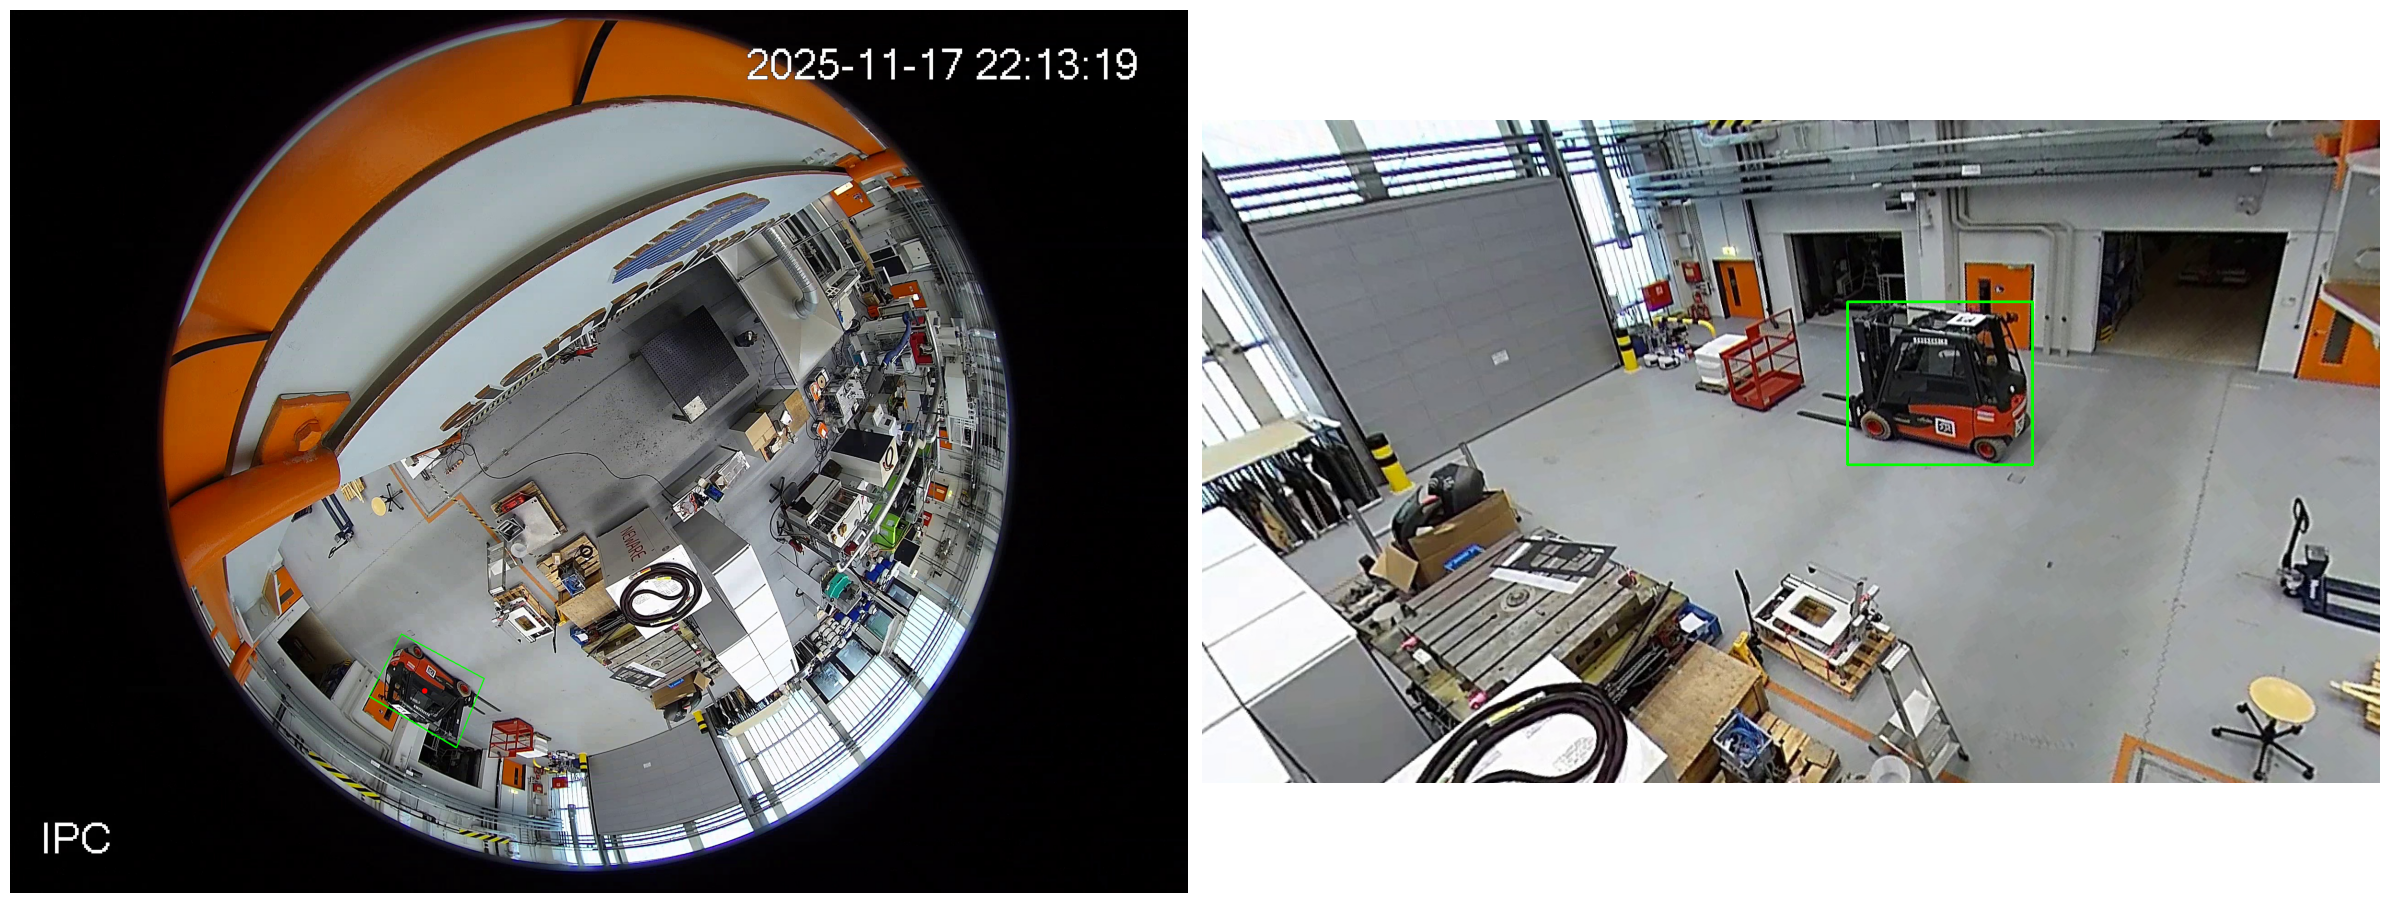

In [ ]:
fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708
}


cam_settings = [
    {"cx": 1296.0, "cy": 972.0, "fov": 90.0, "pitch": 58.0, "yaw": -18.0},
    # {"cx": 1296.0, "cy": 972.0, "fov": 90.0, "pitch": 54.0, "yaw": 48.0},
    {"cx": 1296.0, "cy": 972.0, "fov": 90.0, "pitch": 54.0, "yaw": 250.0},
    {"cx": 1296.0, "cy": 972.0, "fov": 90.0, "pitch": 28.0, "yaw": 150.0},
    {"cx": 1296.0, "cy": 972.0, "fov": 90.0, "pitch": 58.0, "yaw": 294.0},
]


model = YOLO("16_09_25_SENd_v2.5_10s_960.pt")

# Load images
rect_img = cv2.imread("dect/229_view4.jpg")
fish_img = cv2.imread("dect/229_fisheye.jpg")
n = 3
# rect_img = cv2.imread("dect/233_view4_yaw250_p54__.jpg")
# fish_img = cv2.imread("dect/233_fisheye.jpg")
# n = 1
results = model(rect_img)

bb_points_fisheye = []
def compute_basis(yaw_deg, pitch_deg):
    yaw_deg_corrected = yaw_deg - 90.0
    yaw, pitch = np.deg2rad([yaw_deg_corrected, pitch_deg])

    Rz = np.array([
        [ np.cos(-yaw), -np.sin(-yaw), 0],
        [ np.sin(-yaw),  np.cos(-yaw), 0],
        [ 0,             0,            1]
    ])
    Rx = np.array([
        [ 1, 0,           0          ],
        [ 0, np.cos(pitch), -np.sin(pitch)],
        [ 0, np.sin(pitch),  np.cos(pitch)]
    ])
    R_ = Rx @ Rz
    R = np.diag([1, -1, 1]) @ R_
    return R

def rect_to_fisheye_point(u, v, view_params, fisheye_params):
    Hr, Wr = 720, 1280
    cx_r, cy_r = Wr / 2, Hr / 2
    fov = view_params["fov"]
    f = (Wr / 2) / np.tan(np.deg2rad(fov / 2))
    x = (u - cx_r) / f
    y = (v - cy_r) / f
    z = 1
    ray_rect = np.array([x, y, z])
    ray_rect /= np.linalg.norm(ray_rect)
    Rot = compute_basis(view_params["yaw"], view_params["pitch"])
    ray_fish = Rot.T @ ray_rect
    Xf, Yf, Zf = ray_fish
    theta = np.arccos(np.clip(Zf, -1, 1))
    phi = np.arctan2(Yf, Xf)
    radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]
    cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
    r = (theta / theta_max) * radius
    u_f = cx_f + r * np.cos(phi)
    v_f = cy_f - r * np.sin(phi)
    return (int(u_f), int(v_f))

    
for result in results:
    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        if cls == 1:
            rect_pts = [(x1, y1),(x2, y1),(x2, y2),(x1, y2)]
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            print(cx,cy)

            fish_pts = []
            for (px, py) in rect_pts:
                u_f, v_f = rect_to_fisheye_point(px, py, cam_settings[n], fisheye_params)
                fish_pts.append((u_f, v_f))

            cx_f, cy_f = rect_to_fisheye_point(cx, cy,  cam_settings[n], fisheye_params)
            fish_pts_np = np.array(fish_pts, np.int32)
            cv2.polylines(fish_img, [fish_pts_np], True, (0,255,0), 2)
            cv2.circle(fish_img, (cx_f, cy_f), 6, (0,0,255), -1)
            cv2.rectangle(rect_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            bb_points_fisheye.append((fish_pts, (cx_f, cy_f)))


plt.figure(figsize=(24,15))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(fish_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(rect_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


In [37]:
def fisheye_pixel_to_ray(u_f, v_f, fisheye_params):
    cx, cy = fisheye_params["cx"], fisheye_params["cy"]
    radius = fisheye_params["radius"]
    theta_max = fisheye_params["theta_max_rad"]

    dx = u_f - cx
    dy = -(v_f - cy)
    r = np.sqrt(dx*dx + dy*dy)

    theta = (r / radius) * theta_max
    phi = np.arctan2(dy, dx)

    X = np.sin(theta) * np.cos(phi)
    Y = np.sin(theta) * np.sin(phi)
    Z = np.cos(theta)

    return np.array([X, Y, Z]) / np.linalg.norm([X, Y, Z])


def compute_required_fov(fish_pts, fish_center, fisheye_params):
    cx_f, cy_f = fish_center
    center_ray = fisheye_pixel_to_ray(cx_f, cy_f, fisheye_params)

    angles = []
    for (u_f, v_f) in fish_pts:
        ray = fisheye_pixel_to_ray(u_f, v_f, fisheye_params)
        angle = np.arccos(np.clip(np.dot(center_ray, ray), -1, 1))
        angles.append(angle)

    max_angle = max(angles)
    
    return np.rad2deg(2 * max_angle)
required_fov = compute_required_fov(bb_points_fisheye[0][0],bb_points_fisheye[0][1], fisheye_params)
print("FOV:", required_fov)


FOV: 23.2540081324194


No markers detected
Rect shape:(720, 1280, 3)


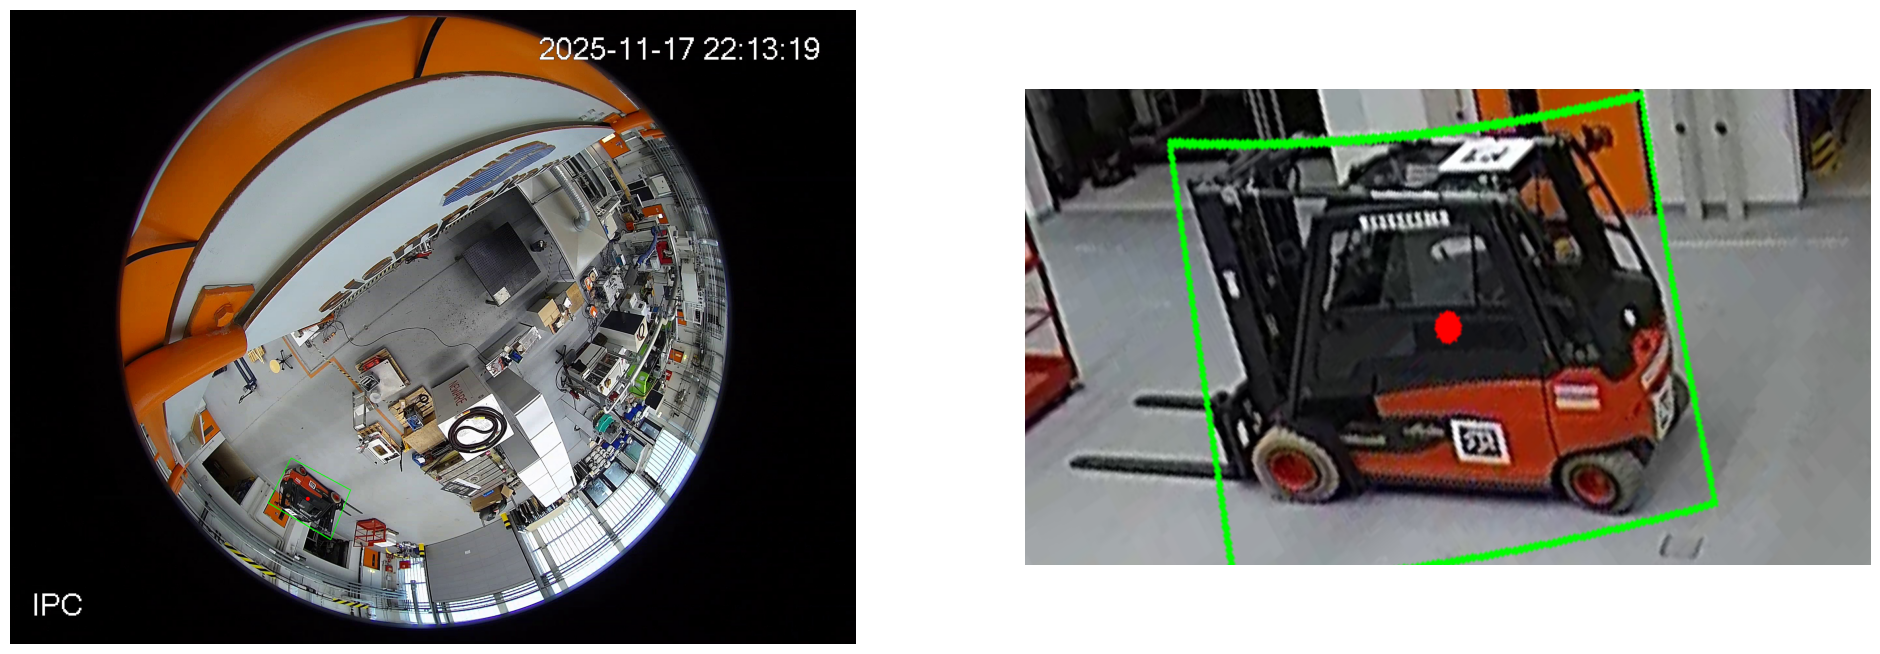

In [40]:

padding_factor = 1.25 
FOV = required_fov * padding_factor


def extract_directional_crop(fisheye_img, yaw_deg, pitch_deg, cx, cy, f_fish, fov_deg=90, out_w=1280, out_h=720):
    yaw = np.deg2rad(yaw_deg)
    pitch = np.deg2rad(pitch_deg)
    fov = np.deg2rad(fov_deg)
    fx = (out_w / 2) / np.tan(fov / 2)
    fy = fx
    cx_o = out_w / 2
    cy_o = out_h / 2
    x = np.linspace(0, out_w - 1, out_w)
    y = np.linspace(0, out_h - 1, out_h)
    xv, yv = np.meshgrid(x, y)
    x_cam = (xv - cx_o) / fx
    y_cam = (yv - cy_o) / fy
    z_cam = np.ones_like(x_cam)

    norm = np.sqrt(x_cam**2 + y_cam**2 + z_cam**2)
    x_cam /= norm
    y_cam /= norm
    z_cam /= norm

    R_yaw = np.array([
        [np.cos(-yaw), -np.sin(-yaw), 0],
        [np.sin(-yaw),  np.cos(-yaw), 0],
        [0,            0,           1]
    ])

    R_pitch = np.array([
        [1, 0,             0],
        [0, np.cos(pitch), -np.sin(pitch)],
        [0, np.sin(pitch),  np.cos(pitch)]
    ])

    R_fix = np.array([
        [0, -1, 0],
        [1,  0, 0],
        [0,  0, 1]
    ])

    R = R_fix@R_yaw @ R_pitch
    rays = np.stack((x_cam, y_cam, z_cam), axis=-1)
    rays_rot = rays @ R.T
    theta = np.arccos(rays_rot[..., 2])
    phi = np.arctan2(rays_rot[..., 1], rays_rot[..., 0])
    r = f_fish * theta
    u = cx + r * np.cos(phi)
    v = cy + r * np.sin(phi)
    map_x = u.astype(np.float32)
    map_y = v.astype(np.float32)
    return cv2.remap(fisheye_img, map_x, map_y, cv2.INTER_LINEAR)

def fisheye_to_rect(fisheye,u_f,v_f, fisheye_params=fisheye_params):
    fisheye=fisheye
    fisheye_cx = fisheye_params["cx"]
    fisheye_cy = fisheye_params["cy"]
    radius = fisheye_params["radius"]
    theta_max = fisheye_params["theta_max_rad"]
    f_fish = radius/theta_max
    dx = u_f - fisheye_cx
    dy = fisheye_cy - v_f          
    r = np.sqrt(dx*dx + dy*dy)
    phi = np.arctan2(dy, dx)          
    theta = (r / radius) * theta_max
    theta = np.clip(theta, 0, theta_max)
    yaw_deg = np.rad2deg(phi)
    if yaw_deg < 0:
     yaw_deg += 360
    pitch_deg = np.rad2deg(theta)

    rect = extract_directional_crop(fisheye, yaw_deg=yaw_deg, pitch_deg=pitch_deg, cx=fisheye_cx, cy= fisheye_cy,f_fish=f_fish, fov_deg=FOV, out_w=1280, out_h=720)
    return rect


fisheye_rgb = cv2.cvtColor(fish_img, cv2.COLOR_BGR2RGB)
u ,v = bb_points_fisheye[0][1]
point_img = cv2.circle(fisheye_rgb,bb_points_fisheye[0][1], 10,(0,255,0),-1)
crop = fisheye_to_rect(fisheye=fish_img,u_f=u,v_f=v,fisheye_params=fisheye_params)
crop_rgb = cv2.cvtColor(crop,cv2.COLOR_BGR2RGB)

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
corners, ids, rejected = detector.detectMarkers(crop)

if ids is not None:
    for i, corner in enumerate(corners):
        c = corner[0]  
        marker_id = ids[i][0]
        cx = int(np.mean(c[:,0]))
        cy = int(np.mean(c[:,1]))

        print(f"Marker ID:{marker_id}, Center:{(cx, cy)}")
        cv2.circle(crop,(cx,cy),4,(0,255,0),-1)
        text = f"id:{marker_id}"
        cv2.putText(crop,text,(cx+20,cy+20),cv2.FONT_HERSHEY_COMPLEX_SMALL,2,(255,0,0),4,cv2.LINE_AA)
    
else:
    print("No markers detected")

print(f"Rect shape:{crop_rgb.shape}")
plt.figure(figsize=(24,15))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(fish_img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(crop,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

